In [3]:
pip install numpy pandas matplotlib xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.6 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import xlsxwriter
import os
import numpy as np

In [6]:
df=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Aminu_Assignment/Aminu_task2.xlsx",sheet_name="Sheet1")
df.head()

,order_id,date,account_code,product_name,quantity,appointment_date,category,unit_price,treat_disc,retail_disc,...,order_status,fulfillment_stage,account_manager,fulfillment_owner,priority_flag,expected_dispatch_date,internal_notes,days_to_appointment,days_until_appointment,order_month
0,2500,2025-11-01,A,FG - AHA Face Wash - 100ml,1,2025-11-12,Cleanser,1228.81,0.0,0.36,...,Overdue – Past Appointment,Overdue - In Warehouse,Key Account Manager,Team D (Retail),High – Past Due,2025-11-10,Priority: High – Past Due | R/T not verified,11.0,-116.0,November
1,2500,2025-11-01,A,FG - Sea Salt Body Scrub - 200ml,1,2025-11-12,Body,2245.76,0.0,0.36,...,Overdue – Past Appointment,Overdue - In Warehouse,Key Account Manager,Team D (Retail),High – Past Due,2025-11-10,Priority: High – Past Due | R/T not verified,11.0,-116.0,November
2,2500,2025-11-01,A,FG - Radiance Face Oil - 30ml,1,2025-11-12,Oil,3008.47,0.0,0.36,...,Overdue – Past Appointment,Overdue - In Warehouse,Key Account Manager,Team D (Retail),High – Past Due,2025-11-10,Priority: High – Past Due | R/T not verified,11.0,-116.0,November
3,2500,2025-11-01,A,FG - Melting Balm Cleanser - 50ml,1,2025-11-12,Cleanser,1016.95,0.0,0.36,...,Overdue – Past Appointment,Overdue - In Warehouse,Key Account Manager,Team D (Retail),High – Past Due,2025-11-10,Priority: High – Past Due | R/T not verified,11.0,-116.0,November
4,2500,2025-11-01,A,FG - Copper Peptide Serum - 30ml,3,2025-11-12,Serum,3898.31,0.0,0.36,...,Overdue – Past Appointment,Overdue - In Warehouse,Key Account Manager,Team D (Retail),High – Past Due,2025-11-10,Priority: High – Past Due | R/T not verified,11.0,-116.0,November


In [7]:
order_level = df.groupby('order_id').agg(
    total_value      = ('final_price', 'sum'),
    total_quantity   = ('quantity', 'sum'),
    num_skus         = ('product_name', 'count'),
    retail_skus      = ('product_type', lambda x: sum('Retail' in str(t) and 'Sample' not in str(t) for t in x)),
    professional_skus = ('product_type', lambda x: sum('Professional' in str(t) for t in x)),
    order_status     = ('order_status', 'first')
).reset_index()
order_level['retail_pct'] = (order_level['retail_skus'] / order_level['num_skus'] * 100).round(1)
order_level['professional_pct'] = (order_level['professional_skus'] / order_level['num_skus'] * 100).round(1)
order_level.head()

,order_id,total_value,total_quantity,num_skus,retail_skus,professional_skus,order_status,retail_pct,professional_pct
0,2500,46496.08,37,7,6,1,Overdue – Past Appointment,85.7,14.3
1,2501,0.00,100,1,0,1,Overdue – Past Appointment,0.0,100.0
2,2502,0.00,70,1,0,1,Overdue – Past Appointment,0.0,100.0
3,2503,0.00,70,1,0,1,Overdue – Past Appointment,0.0,100.0
4,2504,0.00,60,1,0,1,Overdue – Past Appointment,0.0,100.0


In [8]:
img_dir = 'dashboard_images'
os.makedirs(img_dir, exist_ok=True)

In [17]:
import seaborn as sns
colors = sns.color_palette("husl", 8)
print(colors[0])

(0.9677975592919913, 0.44127456009157356, 0.5358103155058701)


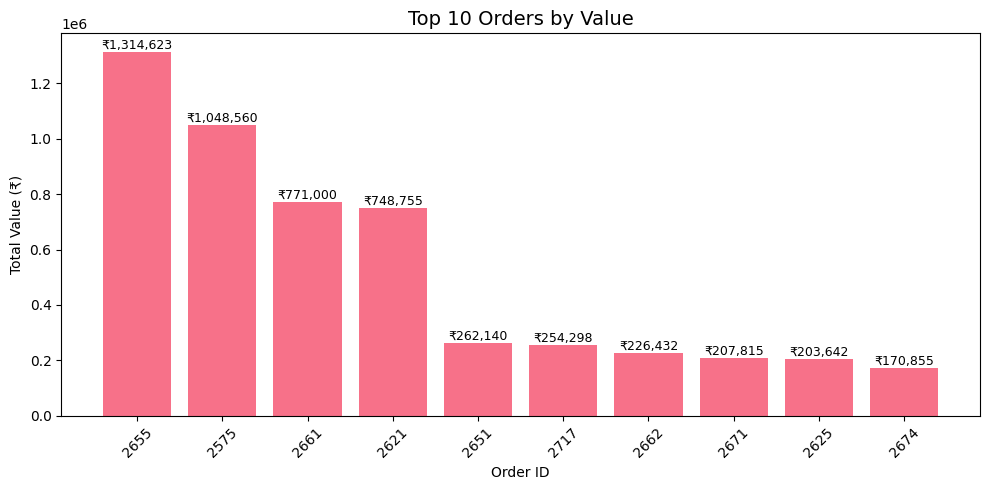

In [19]:
#top 10 valued orders
top10 = order_level.nlargest(10, 'total_value')[['order_id', 'total_value']]
plt.figure(figsize=(10,5))
bars = plt.bar(range(len(top10)), top10['total_value'], color=colors[0])
plt.title('Top 10 Orders by Value', fontsize=14)
plt.xlabel('Order ID')
plt.ylabel('Total Value (₹)')
plt.xticks(range(len(top10)), top10['order_id'].astype(str), rotation=45)
for bar, val in zip(bars, top10['total_value']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{img_dir}/top10.png', dpi=100)
plt.show()
plt.close()

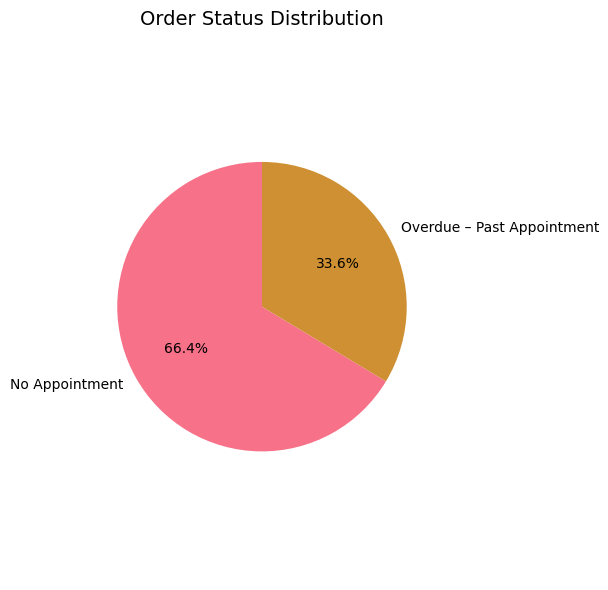

In [21]:
status_counts = order_level['order_status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90,
        colors=colors[:4])
plt.title('Order Status Distribution', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.savefig(f'{img_dir}/status_pie.png', dpi=100)
plt.show()
plt.close()

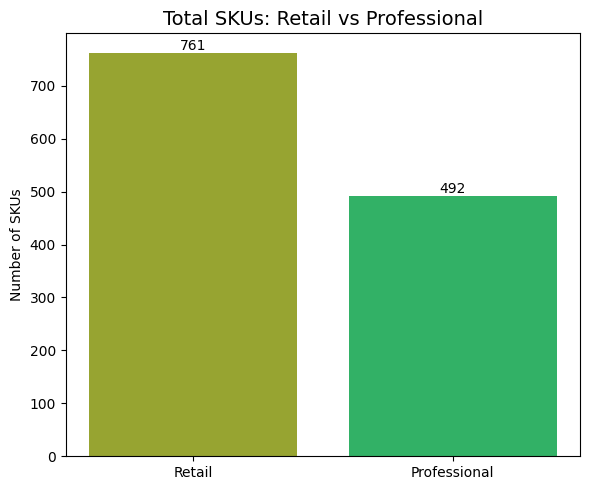

In [27]:
total_retail = order_level['retail_skus'].sum()
total_prof = order_level['professional_skus'].sum()
plt.figure(figsize=(6,5))
bars = plt.bar(['Retail', 'Professional'], [total_retail, total_prof],
               color=colors[2:4])
plt.title('Total SKUs: Retail vs Professional', fontsize=14)
plt.ylabel('Number of SKUs')
# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(f'{img_dir}/total_mix.png', dpi=100)
plt.show()
plt.close()

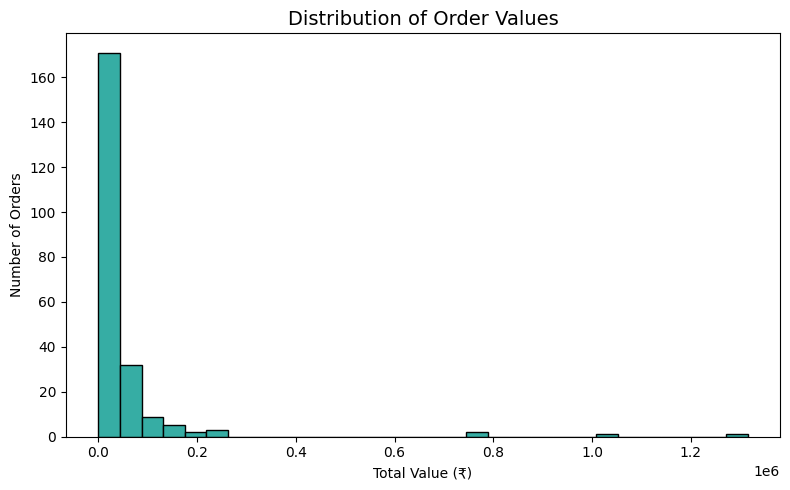

In [28]:
plt.figure(figsize=(8,5))
plt.hist(order_level['total_value'], bins=30, color=colors[4], edgecolor='black')
plt.title('Distribution of Order Values', fontsize=14)
plt.xlabel('Total Value (₹)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(f'{img_dir}/value_hist.png', dpi=100)
plt.show()
plt.close()


In [32]:
excel_file = '/content/drive/MyDrive/Colab Notebooks/Aminu_Assignment/Aminu_task3.xlsx'
with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    order_level.to_excel(writer, sheet_name='Order Summary', index=False)
    workbook = writer.book
    dashboard = workbook.add_worksheet('Dashboard')
    title_format = workbook.add_format({'bold': True, 'font_size': 16, 'align': 'center'})
    dashboard.merge_range('A1:H1', 'Order Level Dashboard', title_format)
    dashboard.insert_image('A3', f'{img_dir}/top10.png', {'x_scale': 0.7, 'y_scale': 0.7})
    dashboard.insert_image('J3', f'{img_dir}/status_pie.png', {'x_scale': 0.7, 'y_scale': 0.7})
    dashboard.insert_image('A23', f'{img_dir}/total_mix.png', {'x_scale': 0.7, 'y_scale': 0.7})
    dashboard.insert_image('J23', f'{img_dir}/value_hist.png', {'x_scale': 0.7, 'y_scale': 0.7})
    stats_format = workbook.add_format({'bold': True, 'font_size': 12})
    dashboard.write('A20', 'Total Orders:', stats_format)
    dashboard.write('B20', len(order_level))
    dashboard.write('A21', 'Total Revenue:', stats_format)
    dashboard.write('B21', f'₹{order_level["total_value"].sum():,.0f}')
print("Task 3 complete")


Task 3 complete


In [33]:
#task 4
account_summary = df.groupby('account_code').agg(
    orders       = ('order_id', 'nunique'),
    revenue      = ('final_price', 'sum'),
    account_type = ('account_type', 'first')
).reset_index().sort_values('revenue', ascending=False)

account_summary['avg_order_value'] = (account_summary['revenue'] / account_summary['orders']).round(2)
account_summary.head()


,account_code,orders,revenue,account_type,avg_order_value
61,R,4,2090002.19,Both,522500.55
62,S,1,1314622.68,Both,1314622.68
33,F,15,1137601.32,Both,75840.09
29,B,12,925409.17,Both,77117.43
58,O,2,754155.02,Both,377077.51


In [34]:
img_dir = 'account_images'
os.makedirs(img_dir, exist_ok=True)


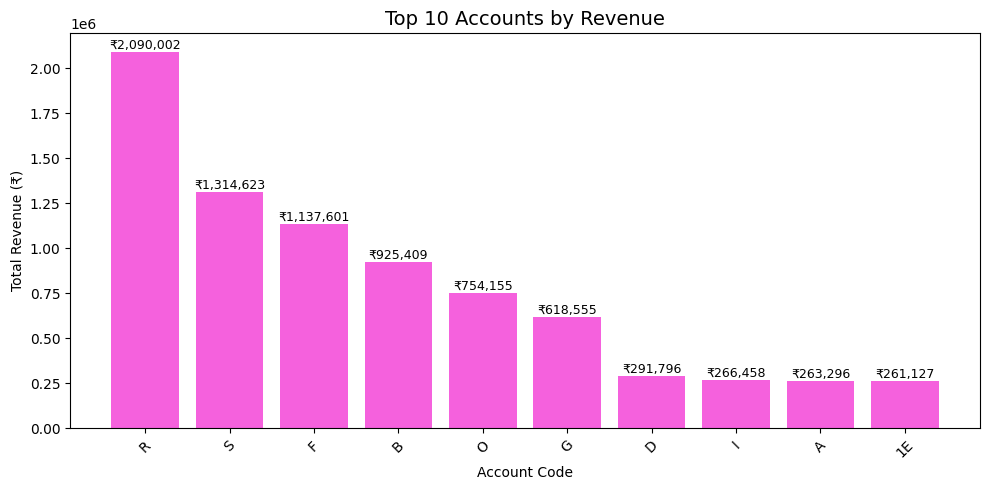

In [38]:
#top 10 acc by revenue
top10_acc = account_summary.head(10)
plt.figure(figsize=(10,5))
bars = plt.bar(range(len(top10_acc)), top10_acc['revenue'], color=colors[7])
plt.title('Top 10 Accounts by Revenue', fontsize=14)
plt.xlabel('Account Code')
plt.ylabel('Total Revenue (₹)')
plt.xticks(range(len(top10_acc)), top10_acc['account_code'], rotation=45)
for bar, val in zip(bars, top10_acc['revenue']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{img_dir}/top10_accounts.png', dpi=100)
plt.show()
plt.close()

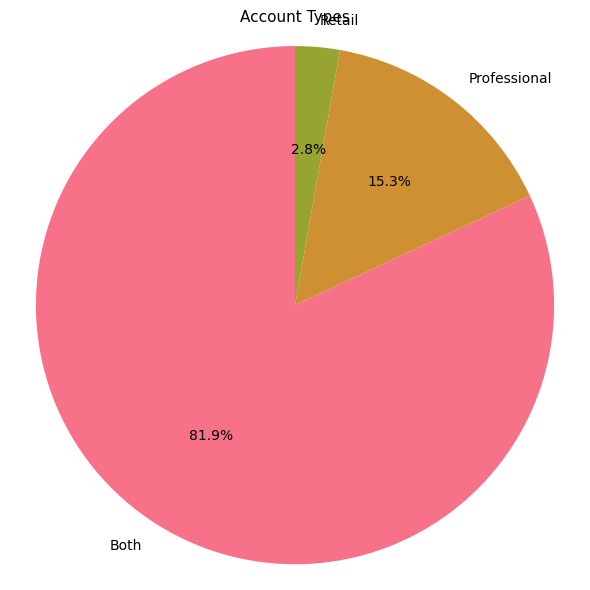

In [43]:
#account_type
type_counts = account_summary['account_type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90,
        colors=colors[:-4])
plt.title('Account Types', fontsize=11)
plt.axis('equal')
plt.tight_layout()
plt.savefig(f'{img_dir}/account_types_pie.png', dpi=100)
plt.show()
plt.close()


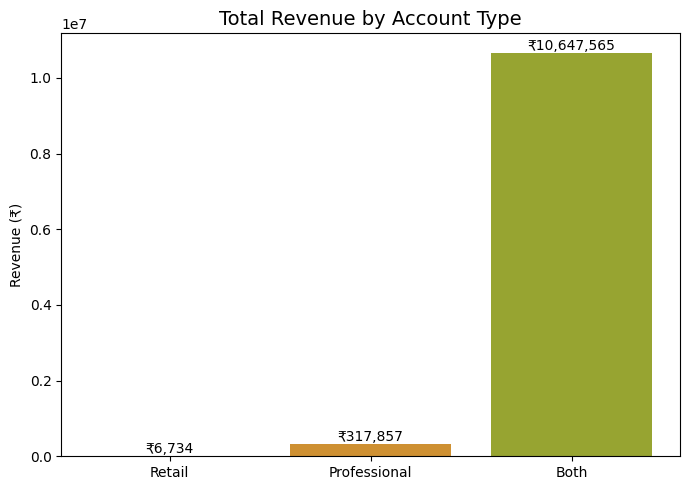

In [46]:
#revenue by account type
revenue_by_type = account_summary.groupby('account_type')['revenue'].sum().sort_values()
plt.figure(figsize=(7,5))
bars = plt.bar(revenue_by_type.index, revenue_by_type.values, color=colors[:3])
plt.title('Total Revenue by Account Type', fontsize=14)
plt.ylabel('Revenue (₹)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'₹{height:,.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(f'{img_dir}/revenue_by_type.png', dpi=100)
plt.show()
plt.close()

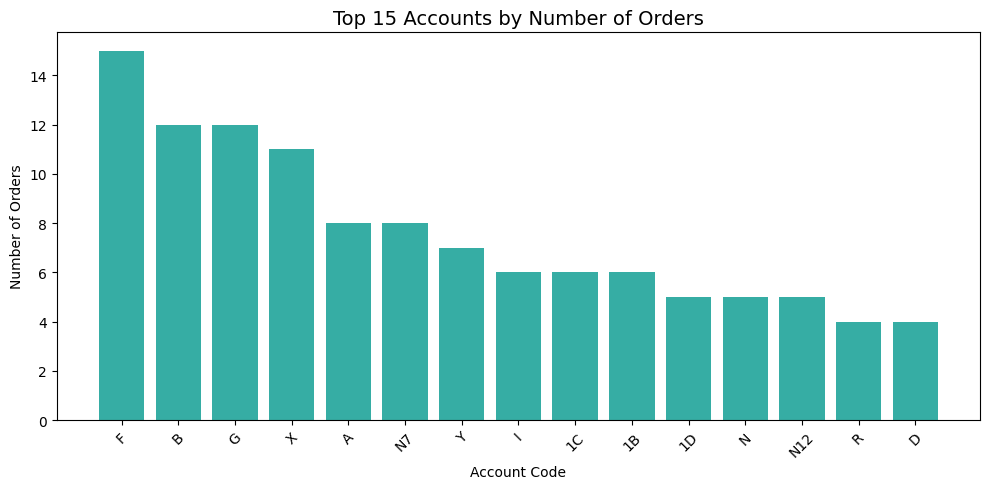

In [47]:
#Number of orders per account : Top 15
top15_orders = account_summary.nlargest(15, 'orders')[['account_code', 'orders']]
plt.figure(figsize=(10,5))
plt.bar(range(len(top15_orders)), top15_orders['orders'], color=colors[4])
plt.title('Top 15 Accounts by Number of Orders', fontsize=14)
plt.xlabel('Account Code')
plt.ylabel('Number of Orders')
plt.xticks(range(len(top15_orders)), top15_orders['account_code'], rotation=45)
plt.tight_layout()
plt.savefig(f'{img_dir}/top15_orders.png', dpi=100)
plt.show()
plt.close()

In [48]:
excel_file = '/content/drive/MyDrive/Colab Notebooks/Aminu_Assignment/Aminu_task4.xlsx'
with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    account_summary.to_excel(writer, sheet_name='Account Summary', index=False)

    workbook = writer.book
    dashboard = workbook.add_worksheet('Dashboard')

    title_format = workbook.add_format({'bold': True, 'font_size': 16, 'align': 'center'})
    dashboard.merge_range('A1:H1', 'Account Level Dashboard', title_format)

    dashboard.insert_image('A3', f'{img_dir}/top10_accounts.png', {'x_scale': 0.7, 'y_scale': 0.7})
    dashboard.insert_image('J3', f'{img_dir}/account_types_pie.png', {'x_scale': 0.7, 'y_scale': 0.7})
    dashboard.insert_image('A23', f'{img_dir}/revenue_by_type.png', {'x_scale': 0.7, 'y_scale': 0.7})
    dashboard.insert_image('J23', f'{img_dir}/top15_orders.png', {'x_scale': 0.7, 'y_scale': 0.7})
print("Task 4 completed ")



Task 4 completed 
